# Machine Learning Lab 6

Name: Saba Mahar  
Student ID: 023-24-0141  
Section: H  
GitHub Profile: https://github.com/sabamahar304/ML-Lab-6  
Kaggle Profile: https://www.kaggle.com/  

Dataset: clean_churn  
Dataset Source: Kaggle

Part 1 — Problem Definition & Dataset Verification

In [1]:
#Task1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("clean_churn.csv")

print("Shape:", df.shape)
print(df.dtypes)
print("Missing values:", df.isnull().sum().sum())

Shape: (7021, 20)
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object
Missing values: 0


Task 2:
The Lab 3 Decision Tree (max_depth=8) achieved accuracy 0.7932, precision 0.6311, recall 0.5256, and F1-score 0.5735 on the test set. The Lab 4 Random Forest (200 trees) achieved accuracy 0.7889, precision 0.6316, recall 0.4852, and F1-score 0.5488. These two results are the benchmarks for this lab, and the Decision Tree is the stronger of the two on recall and F1.

Part 2 — Feature Scaling & Preparation

In [2]:
#Task3

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()

y = df["Churn"].map({"No": 0, "Yes": 1})
X = df.drop("Churn", axis=1)

X = pd.get_dummies(X, drop_first=True)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7010, 30)
y shape: (7010,)


Task 4:
KNN classifies by straight-line distance, so features with large ranges such as TotalCharges (up to about 8,000) and MonthlyCharges would dominate small-range features such as tenure or the 0/1 dummy columns unless everything is put on a comparable scale. Logistic Regression is also helped by scaling because its optimization converges more smoothly and its regularization treats all coefficients fairly when features share a similar scale. Decision Trees and Random Forests only ask whether a single feature is above or below a threshold, so rescaling a feature does not change any split and scaling was never necessary.

In [3]:
#Task5

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)
print("Train mean (first 3 features):", X_train_scaled.mean(axis=0)[:3].round(4))
print("Train std (first 3 features):", X_train_scaled.std(axis=0)[:3].round(4))

X_train_scaled: (5608, 30)
X_test_scaled: (1402, 30)
Train mean (first 3 features): [-0.  0.  0.]
Train std (first 3 features): [1. 1. 1.]


Task 5:
The scaler must be fitted on the training data only because the test set represents unseen data. If the mean and standard deviation were calculated using the test rows too (or the full dataset), information about the test set would leak into the training process (data leakage) and the test results would look better than they truly are. Fitting on the training set and only applying `transform` to the test set keeps the evaluation honest.

Part 3 — Logistic Regression

In [4]:
#Task6

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)

lr.fit(X_train_scaled, y_train)

lr_test_pred = lr.predict(X_test_scaled)

,Metric,Logistic Regression
0,Accuracy,0.808845
1,Precision,0.673401
2,Recall,0.539084
3,F1-Score,0.598802


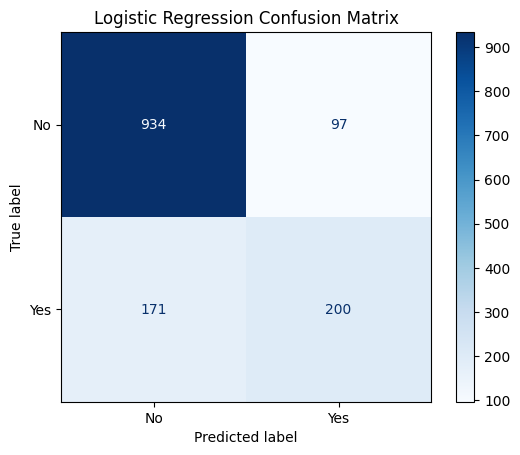

In [5]:
#Task7

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

lr_accuracy = accuracy_score(y_test, lr_test_pred)
lr_precision = precision_score(y_test, lr_test_pred)
lr_recall = recall_score(y_test, lr_test_pred)
lr_f1 = f1_score(y_test, lr_test_pred)

lr_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Logistic Regression": [lr_accuracy, lr_precision, lr_recall, lr_f1]
})

display(lr_results)

ConfusionMatrixDisplay.from_predictions(y_test, lr_test_pred, display_labels=["No", "Yes"], cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [6]:
#Task8

lr_proba = lr.predict_proba(X_test_scaled[:8])

proba_table = pd.DataFrame({
    "P(No)": lr_proba[:, 0],
    "P(Yes)": lr_proba[:, 1],
    "Predicted": lr.predict(X_test_scaled[:8]),
    "Actual": y_test.values[:8]
})

proba_table

,P(No),P(Yes),Predicted,Actual
0,0.635725,0.364275,0,0
1,0.986495,0.013505,0,0
2,0.912384,0.087616,0,0
3,0.698738,0.301262,0,0
4,0.747470,0.252530,0,0
5,0.543442,0.456558,0,1
6,0.892678,0.107322,0,0
7,0.916169,0.083831,0,0


Task 8:
predict_proba returns the model's estimated probability of each class for a customer (column 0 is the probability of No, column 1 is the probability of Yes), and the two values add up to 1. predict() turns this into a decision by choosing Yes (churn) when the probability of Yes is above 0.5 and No otherwise, so for example a customer with P(Yes) = 0.36 is predicted as No.

Part 4 — KNN & Choosing K

In [7]:
#Task9

from sklearn.neighbors import KNeighborsClassifier

k_values = [1, 3, 5, 7, 9, 11, 15, 21]
knn_accuracy = []
knn_f1 = []

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train_scaled, y_train)
    knn_k_pred = knn_k.predict(X_test_scaled)
    knn_accuracy.append(accuracy_score(y_test, knn_k_pred))
    knn_f1.append(f1_score(y_test, knn_k_pred))

knn_k_results = pd.DataFrame({
    "K": k_values,
    "Accuracy": knn_accuracy,
    "F1-Score": knn_f1
})

knn_k_results

,K,Accuracy,F1-Score
0,1,0.707561,0.459103
1,3,0.738231,0.492393
2,5,0.748930,0.505618
3,7,0.762482,0.523605
4,9,0.769615,0.540541
5,11,0.771041,0.549790
6,15,0.784593,0.566092
7,21,0.780314,0.560000


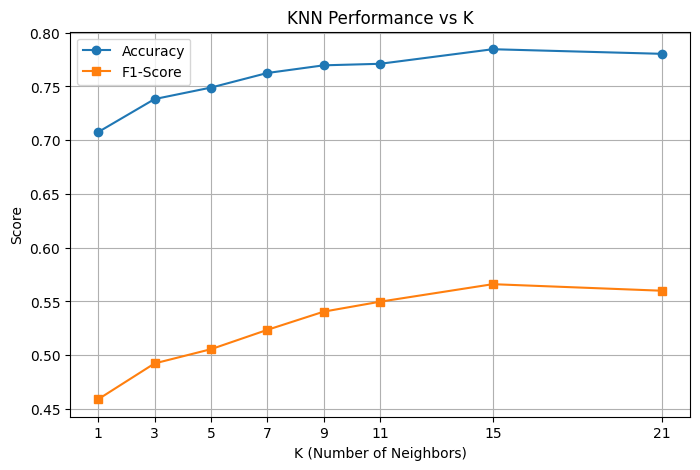

In [8]:
#Task10

plt.figure(figsize=(8, 5))
plt.plot(k_values, knn_accuracy, marker="o", label="Accuracy")
plt.plot(k_values, knn_f1, marker="s", label="F1-Score")
plt.xticks(k_values)
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Score")
plt.title("KNN Performance vs K")
plt.legend()
plt.grid(True)
plt.show()

Task 10:
I would choose K = 15, because both accuracy and F1-score rise steadily as K increases from 1 and peak at K = 15 (F1 about 0.566), then fall slightly at K = 21. The smallest value, K = 1, gives the worst scores because the model copies its single nearest neighbor and overfits to noise, while the largest value tested, K = 21, starts to underfit by averaging over too many unrelated customers.

,Metric,KNN (K=15)
0,Accuracy,0.784593
1,Precision,0.606154
2,Recall,0.530997
3,F1-Score,0.566092


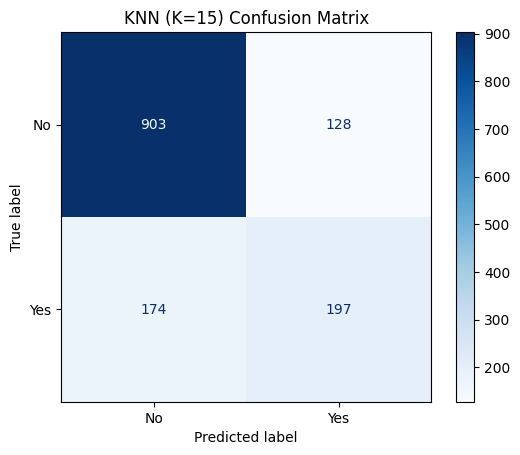

In [9]:
#Task11

chosen_k = 15

knn = KNeighborsClassifier(n_neighbors=chosen_k)
knn.fit(X_train_scaled, y_train)

knn_test_pred = knn.predict(X_test_scaled)

knn_final_accuracy = accuracy_score(y_test, knn_test_pred)
knn_final_precision = precision_score(y_test, knn_test_pred)
knn_final_recall = recall_score(y_test, knn_test_pred)
knn_final_f1 = f1_score(y_test, knn_test_pred)

knn_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "KNN (K=15)": [knn_final_accuracy, knn_final_precision, knn_final_recall, knn_final_f1]
})

display(knn_results)

ConfusionMatrixDisplay.from_predictions(y_test, knn_test_pred, display_labels=["No", "Yes"], cmap="Blues")
plt.title("KNN (K=15) Confusion Matrix")
plt.show()

Part 5 — Model Comparison (4 Models)

In [10]:
#Task12

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

dt = DecisionTreeClassifier(max_depth=8, random_state=42)
dt.fit(X_train, y_train)
dt_test_pred = dt.predict(X_test)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_test_pred = rf.predict(X_test)

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Decision Tree": [accuracy_score(y_test, dt_test_pred), precision_score(y_test, dt_test_pred), recall_score(y_test, dt_test_pred), f1_score(y_test, dt_test_pred)],
    "Random Forest": [accuracy_score(y_test, rf_test_pred), precision_score(y_test, rf_test_pred), recall_score(y_test, rf_test_pred), f1_score(y_test, rf_test_pred)],
    "Logistic Regression": [lr_accuracy, lr_precision, lr_recall, lr_f1],
    "KNN (K=15)": [knn_final_accuracy, knn_final_precision, knn_final_recall, knn_final_f1]
})

comparison

,Metric,Decision Tree,Random Forest,Logistic Regression,KNN (K=15)
0,Accuracy,0.793153,0.788873,0.808845,0.784593
1,Precision,0.631068,0.631579,0.673401,0.606154
2,Recall,0.525606,0.485175,0.539084,0.530997
3,F1-Score,0.573529,0.548780,0.598802,0.566092


Task 13:
Logistic Regression performs best overall, leading on all four metrics (accuracy 0.8088, precision 0.6734, recall 0.5391, F1-score 0.5988), although its margin over the others is modest. The ranking of the remaining models does change with the metric: the Decision Tree is second on accuracy and F1-score, KNN is second on recall but last on precision, and the Random Forest is second on precision but last on recall and F1-score. Because only about 26.5% of customers churn, accuracy is misleading (always predicting No would already score about 73.5%), so recall and F1-score should carry the most weight, since the goal is to find the customers who will actually leave without too many false alarms.

Part 6 — Coefficient Interpretation

In [11]:
#Task14

scale = pd.Series(scaler.scale_, index=X.columns)
is_binary = X_train.nunique() == 2

def interpret(feature, coef):
    if is_binary[feature]:
        return f"Customers with {feature} have roughly {np.exp(coef / scale[feature]):.2f}x the odds of churning compared with those without it, holding other features constant (odds ratio above is per 1 std dev)."
    return f"Each 1 standard deviation increase in {feature} multiplies the odds of churning by about {np.exp(coef):.2f}x, holding other features constant."

print("Intercept:", round(lr.intercept_[0], 4))

coef_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_[0],
})
coef_table["Odds Ratio"] = np.exp(coef_table["Coefficient"])
coef_table["Interpretation"] = [interpret(f, c) for f, c in zip(coef_table["Feature"], coef_table["Coefficient"])]

coef_table = coef_table.reindex(coef_table["Coefficient"].abs().sort_values(ascending=False).index).reset_index(drop=True)

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", None)
coef_table

Intercept: -1.7228


,Feature,Coefficient,Odds Ratio,Interpretation
0,tenure,-1.417202,0.242391,"Each 1 standard deviation increase in tenure multiplies the odds of churning by about 0.24x, holding other features constant."
1,TotalCharges,0.726308,2.067434,"Each 1 standard deviation increase in TotalCharges multiplies the odds of churning by about 2.07x, holding other features constant."
2,Contract_Two year,-0.571146,0.564878,"Customers with Contract_Two year have roughly 0.26x the odds of churning compared with those without it, holding other features constant (odds ratio above is per 1 std dev)."
3,InternetService_Fiber optic,0.517509,1.677843,"Customers with InternetService_Fiber optic have roughly 2.83x the odds of churning compared with those without it, holding other features constant (odds ratio above is per 1 std dev)."
4,MonthlyCharges,-0.330064,0.718878,"Each 1 standard deviation increase in MonthlyCharges multiplies the odds of churning by about 0.72x, holding other features constant."
5,Contract_One year,-0.279345,0.756279,"Customers with Contract_One year have roughly 0.50x the odds of churning compared with those without it, holding other features constant (odds ratio above is per 1 std dev)."
6,PaperlessBilling_Yes,0.184816,1.202997,"Customers with PaperlessBilling_Yes have roughly 1.46x the odds of churning compared with those without it, holding other features constant (odds ratio above is per 1 std dev)."
7,MultipleLines_Yes,0.154627,1.167222,"Customers with MultipleLines_Yes have roughly 1.37x the odds of churning compared with those without it, holding other features constant (odds ratio above is per 1 std dev)."
8,PaymentMethod_Electronic check,0.149189,1.160892,"Customers with PaymentMethod_Electronic check have roughly 1.37x the odds of churning compared with those without it, holding other features constant (odds ratio above is per 1 std dev)."
9,TechSupport_Yes,-0.142096,0.867538,"Customers with TechSupport_Yes have roughly 0.73x the odds of churning compared with those without it, holding other features constant (odds ratio above is per 1 std dev)."


In [12]:
#Task15

dt_importance = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=False)

dt_importance.head(6)

tenure                         0.321495
InternetService_Fiber optic    0.260086
TotalCharges                   0.105608
MonthlyCharges                 0.077483
Contract_Two year              0.043749
Contract_One year              0.026861
dtype: float64

Task 15:
The largest Logistic Regression effects mostly agree with earlier labs: tenure has the strongest effect (odds ratio about 0.24 per standard deviation, so longer-tenure customers churn far less), Contract_Two year lowers the odds of churning, and Fiber optic internet raises them. This matches Lab 2's EDA, where short-tenure customers, month-to-month contracts (42.7% churn) and Fiber optic (41.9% churn) stood out, and Lab 3's Decision Tree, whose top features are tenure (0.32), Fiber optic (0.26), TotalCharges, MonthlyCharges and the contract columns. The disagreements are that MonthlyCharges has a negative coefficient here (odds ratio about 0.72) even though Lab 2 showed churners pay higher monthly charges, and TotalCharges has a large positive one (about 2.07). This happens because tenure, MonthlyCharges and TotalCharges are strongly related to each other (TotalCharges is roughly tenure times monthly charge), so each coefficient shows the effect of a feature after holding the others fixed, not its effect on its own.

Part 7 — Final Model Selection & Conclusion

Task 16:
I select Logistic Regression as the final model, because in the Part 5 table it is the best model on every metric (accuracy 0.8088, precision 0.6734, recall 0.5391, F1-score 0.5988) and not just on one, which makes its lead more trustworthy. Its advantage over the Decision Tree is modest (about 0.025 in F1-score) and comes from a single train/test split, and Lab 4's cross-validation lesson warns that one split can be noisy, so I would confirm the ranking with cross-validation before deploying. It is also simple, stable, and its odds ratios are easy to explain to a business audience.

Task 17:
Logistic Regression, today's best model, beats the best model from Labs 3–4 (the Decision Tree, F1-score 0.5735) with an F1-score of 0.5988, and it also improves accuracy (0.8088 vs 0.7932) and precision (0.6734 vs 0.6311). Feature scaling put tenure, MonthlyCharges and TotalCharges on the same scale as the 0/1 dummy columns, which KNN needed so that its distances were not dominated by the large-valued charge columns, and it made the Logistic Regression coefficients comparable across features; it made no difference to the tree models. The remaining limitation is that recall is only about 54%, so the model still misses almost half of the customers who actually churn. Its linear form cannot capture complex interactions, and the correlated features (tenure, MonthlyCharges, TotalCharges) make some individual coefficients hard to interpret. The results also come from a single train/test split, so they may shift slightly with a different split. Next I would use cross-validation to confirm the ranking, tune the regularization strength, and handle the class imbalance directly, for example with class weights or by lowering the 0.5 decision threshold to catch more churners.